# How much of the VQE result is real, and how much is the optimizer?

Every VQE number in `results/vqe_sim/` and `results/vqe_gpu/` came from a single
optimization run at `seed=0`. That is one draw from a distribution: the Hamiltonian
Variational Ansatz is trained by gradient descent on a non-convex landscape, so a
different random initialization lands in a different local minimum and reports a
different energy.

This notebook repeats the sweep over **8 seeds per point** and asks, for each effect
the write-up wants to claim, whether the effect is bigger than the spread between
seeds. Some are. One is not, and that is the useful part.

The data is `results/vqe_seeds/`, produced by `src/vqe_seeds.py`. Training settings
match the published runs exactly (`n_steps=600`, `stepsize=0.1`, `lightning.qubit`
with adjoint differentiation), so the seed is the only thing that changes.

**These numbers do not reproduce `results/vqe_sim/` exactly, and are not meant to.**
That set was produced by the earlier autograd optimizer, before the JAX/optax
rewrite. The last section measures how much that change alone moves a result — the
answer turns out to matter for how the old numbers should be described.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if (Path.cwd() / ".." / "src").exists() else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import json
import math

import matplotlib.pyplot as plt
import numpy as np

## Loading the ensemble

`summary.json` is written by `python -m src.vqe_seeds --config configs/vqe_seed_ensemble.yaml --summarize`.
It groups the individual runs by `(L, h, n_layers)` and records mean, standard
deviation, median and quartiles across the seeds for each group.

In [2]:
summary_path = REPO_ROOT / "results" / "vqe_seeds" / "summary.json"
summary = json.loads(summary_path.read_text())

# Key by (L, h, n_layers) so configurations are easy to look up and compare.
ens = {(e["L"], round(e["h"], 3), e["n_layers"]): e for e in summary.values()}

n_runs = sum(e["rel_error"]["n"] for e in ens.values())
print(f"{len(ens)} configurations, {n_runs} individual optimization runs")
print(f"seeds per configuration: {sorted({e['rel_error']['n'] for e in ens.values()})}")

76 configurations, 608 individual optimization runs
seeds per configuration: [8]


## The spread, at the published depth

This is the same table the earlier write-up reported as single numbers, now with the
seed-to-seed standard deviation next to each one. The mean and the standard deviation
are both in percent relative error.

Two things stand out immediately: the spread is small in the paramagnetic phase and at
small `L`, and it becomes comparable to the value itself at `h=0.4` for large `L`.

In [3]:
h_values = [0.4, 0.8, 0.95, 1.0, 1.05, 1.2, 1.6]
L_values = [L for L in (4, 6, 8, 10, 12, 16, 20, 24) if (L, 0.4, 10) in ens]

header = "L    " + "".join(f"{'h=' + str(h):>17}" for h in h_values)
print(header)
print("-" * len(header))
for L in L_values:
    row = f"{L:<5}"
    for h in h_values:
        e = ens.get((L, h, 10))
        if e is None:
            row += f"{'-':>17}"
        else:
            r = e["rel_error"]
            row += f"{r['mean']*100:>9.2f} ±{r['std']*100:<6.2f}"
    print(row)

L                h=0.4            h=0.8           h=0.95            h=1.0           h=1.05            h=1.2            h=1.6
----------------------------------------------------------------------------------------------------------------------------
4         0.09 ±0.12       0.08 ±0.14       0.01 ±0.02       0.03 ±0.02       0.02 ±0.02       0.05 ±0.08       0.05 ±0.08  
6         0.29 ±0.43       0.20 ±0.13       0.14 ±0.09       0.12 ±0.06       0.09 ±0.04       0.11 ±0.18       0.05 ±0.04  
8         2.17 ±0.55       0.84 ±0.35       0.42 ±0.21       0.30 ±0.16       0.19 ±0.09       0.14 ±0.12       0.10 ±0.07  
10        4.12 ±0.72       1.00 ±0.25       0.38 ±0.13       0.64 ±0.48       0.26 ±0.07       0.21 ±0.19       0.10 ±0.08  
12        4.85 ±0.54       1.30 ±0.20       0.49 ±0.15       0.36 ±0.12       0.35 ±0.12       0.33 ±0.50       0.06 ±0.04  
16        6.50 ±2.41       1.46 ±0.19       0.57 ±0.12       0.34 ±0.05       0.30 ±0.08       0.23 ±0.19       0.11 ±0.06  


## The distributions are skewed, not Gaussian

Quoting `mean ± std` assumes the runs scatter symmetrically about a central value.
They do not. Most seeds land close together, and occasionally one falls into a much
worse minimum — so the distribution has a long tail on the high-error side only.

A single tail run drags the mean up and inflates the standard deviation a lot. The
median is the better description of a typical run, and the gap between mean and
median is itself informative: it says the configuration has a failure mode.

In [4]:
# Configurations with the widest spread, showing every individual seed.
widest = sorted(ens.items(), key=lambda kv: -kv[1]["rel_error"]["std"])[:6]
for (L, h, n), e in widest:
    r = e["rel_error"]
    vals = "  ".join(f"{v*100:5.2f}" for v in sorted(r["values"]))
    print(f"L={L:<3} h={h:<5} {n} layers")
    print(f"    seeds (%): {vals}")
    print(f"    mean {r['mean']*100:.2f}   median {r['median']*100:.2f}   "
          f"std {r['std']*100:.2f}   IQR {r['q1']*100:.2f}-{r['q3']*100:.2f}")

L=20  h=1.05  10 layers
    seeds (%):  0.22   0.25   0.25   0.26   0.26   0.35   7.00   8.23
    mean 2.10   median 0.26   std 3.42   IQR 0.25-2.01
L=20  h=1.0   10 layers
    seeds (%):  0.36   0.37   0.38   0.42   0.44   0.55   6.41   7.97
    mean 2.11   median 0.43   std 3.16   IQR 0.38-2.01
L=20  h=1.2   20 layers
    seeds (%):  0.06   0.10   0.12   0.19   0.31   0.75   5.86   6.41
    mean 1.73   median 0.25   std 2.73   IQR 0.11-2.03
L=20  h=1.2   10 layers
    seeds (%):  0.09   0.13   0.13   0.13   0.16   0.17   0.17   7.45
    mean 1.05   median 0.15   std 2.58   IQR 0.13-0.17
L=24  h=1.0   10 layers
    seeds (%):  0.36   0.45   0.51   0.52   0.73   1.20   5.43   6.23
    mean 1.93   median 0.63   std 2.43   IQR 0.49-2.26
L=16  h=0.4   10 layers
    seeds (%):  4.81   5.39   5.54   5.56   5.63   6.06   6.68  12.32
    mean 6.50   median 5.59   std 2.41   IQR 5.50-6.22


### When the seeds split into two groups

Everything above assumes the runs form one cluster with the occasional bad
outlier. Some configurations do not behave that way: near criticality at `L=20`
the optimizer either converges or fails outright, so the seeds fall into two
separated groups with nothing in between.

That breaks both of the summaries used so far. The median lands in the empty gap
and reports a value no run ever produced, and an outlier fence computed from the
quartiles sits above the failed group and flags nothing at all — so the least
reliable configuration in the dataset can come out looking clean.

The fix is a statistic that makes no assumption about shape: simply count how
many seeds exceeded 1% error. It reads correctly whether a configuration is
uniformly good, uniformly bad, tail-afflicted, or split.

In [5]:
def looks_split(entry):
    """True if the seeds fall into two separated groups rather than one cluster."""
    v = sorted(entry["rel_error"]["values"])
    if len(v) < 4:
        return False
    biggest, idx = max((v[i+1] - v[i], i) for i in range(len(v) - 1))
    rest = (v[idx] - v[0]) + (v[-1] - v[idx+1])
    return biggest > rest and biggest > 0.01

# Configurations still being filled in are skipped: fewer than four seeds is
# not enough to say anything about a distribution's shape.
MIN_SEEDS = 4

print(f"{'configuration':<28}{'seeds >1%':>11}{'median':>10}   shape")
for (L, h, n), e in sorted(ens.items()):
    if e["n_above_1pct"] == 0 or e["rel_error"]["n"] < MIN_SEEDS:
        continue
    shape = "SPLIT — median is not a real run" if looks_split(e) else "one cluster"
    print(f"  L={L}, h={h}, {n} layers".ljust(28)
          + f"{e['n_above_1pct']:>6}/{e['rel_error']['n']:<4}"
          + f"{e['rel_error']['median']*100:>9.2f}%   {shape}")

configuration                 seeds >1%    median   shape
  L=6, h=0.4, 10 layers          1/8        0.10%   one cluster
  L=8, h=0.4, 10 layers          8/8        2.18%   one cluster
  L=8, h=0.8, 10 layers          2/8        0.74%   one cluster
  L=10, h=0.4, 10 layers         8/8        3.93%   SPLIT — median is not a real run
  L=10, h=0.8, 10 layers         3/8        0.95%   one cluster
  L=10, h=1.0, 10 layers         2/8        0.45%   one cluster
  L=12, h=0.4, 10 layers         8/8        4.89%   one cluster
  L=12, h=0.8, 10 layers         7/8        1.32%   one cluster
  L=12, h=1.2, 10 layers         1/8        0.17%   SPLIT — median is not a real run
  L=16, h=0.4, 10 layers         8/8        5.59%   SPLIT — median is not a real run
  L=16, h=0.8, 10 layers         8/8        1.39%   one cluster
  L=20, h=0.4, 10 layers         8/8        6.16%   SPLIT — median is not a real run
  L=20, h=0.4, 16 layers         8/8        4.45%   one cluster
  L=20, h=0.4, 20 layers  

### Counting the failures

A run counts as a failure if it is above Tukey's fence for its own configuration
(`> q3 + 1.5 x IQR`) **and** its error exceeds 1%.

Both halves are needed. The fence alone fires on configurations where every seed is
already excellent — at `L=4, h=1.6` all eight seeds are under 0.2%, so flagging the
largest of them as a "failure" would be meaningless. The 1% floor is the tolerance
this project already works to, so it is the natural place to draw the line.

In [6]:
def tail_seeds(entry):
    """Seeds that are both statistical outliers and materially bad (>1% error)."""
    r = entry["rel_error"]
    iqr = r["q3"] - r["q1"]
    if iqr <= 0:
        return []
    return sorted(v for v in r["values"] if v > r["q3"] + 1.5 * iqr and v > 0.01)

total = 0
for (L, h, n), e in sorted(ens.items()):
    bad = tail_seeds(e)
    if bad:
        total += len(bad)
        print(f"L={L:<3} h={h:<5} {n:>2} layers   median {e['rel_error']['median']*100:5.2f}%   "
              f"failed seeds: {', '.join(f'{v*100:.2f}%' for v in bad)}")

print(f"\n{total} failed runs out of {n_runs} ({total/n_runs*100:.1f}%)")
print("With 8 seeds a single failure is consistent with a true failure rate anywhere")
print("from a few percent to roughly 40%, so treat these as counts, not as a rate.")

L=6   h=0.4   10 layers   median  0.10%   failed seeds: 1.30%
L=8   h=0.8   10 layers   median  0.74%   failed seeds: 1.55%
L=10  h=0.4   10 layers   median  3.93%   failed seeds: 5.81%
L=12  h=1.2   10 layers   median  0.17%   failed seeds: 1.56%
L=16  h=0.4   10 layers   median  5.59%   failed seeds: 12.32%
L=20  h=0.4   10 layers   median  6.16%   failed seeds: 11.21%
L=20  h=0.4   20 layers   median  3.51%   failed seeds: 4.38%
L=20  h=0.4   24 layers   median  2.90%   failed seeds: 5.26%
L=20  h=0.4   30 layers   median  2.59%   failed seeds: 3.40%
L=20  h=0.8   10 layers   median  1.82%   failed seeds: 2.47%
L=20  h=0.8   20 layers   median  1.15%   failed seeds: 1.67%
L=20  h=0.8   30 layers   median  1.01%   failed seeds: 2.27%
L=20  h=0.95  10 layers   median  0.56%   failed seeds: 6.33%
L=20  h=0.95  20 layers   median  0.45%   failed seeds: 1.62%
L=20  h=1.0   10 layers   median  0.43%   failed seeds: 6.41%, 7.97%
L=20  h=1.0   20 layers   median  0.40%   failed seeds: 1.44%

## Effect 1: does the error really grow with L at h=0.4?

Yes overall, but not at every step. The jump from `L=6` to `L=8` and from `L=8` to
`L=10` is far larger than the spread. The later steps are not: `L=10` to `L=12` and
`L=12` to `L=16` are both inside the noise individually, even though the endpoints
are clearly different from each other.

`t` below is the difference between two configurations divided by the standard error
of that difference (Welch, unequal variances).

In [7]:
def welch(a, b):
    """Difference in percentage points, its standard error, and t = diff/se."""
    diff = (a["mean"] - b["mean"]) * 100
    se = math.sqrt((a["std"]*100)**2 / a["n"] + (b["std"]*100)**2 / b["n"])
    return diff, se, (diff / se if se > 0 else float("inf"))

prev = None
print(f"{'L':<5}{'mean ± std (%)':<22}{'median':<10}{'step vs previous L'}")
for L in L_values:
    e = ens.get((L, 0.4, 10))
    if e is None:
        continue
    r = e["rel_error"]
    line = f"{L:<5}{r['mean']*100:6.2f} ± {r['std']*100:<11.2f}{r['median']*100:<10.2f}"
    if prev is not None:
        diff, se, t = welch(r, prev)
        line += f"{diff:+6.2f} pp   t = {t:+5.1f}"
    print(line)
    prev = r

L    mean ± std (%)        median    step vs previous L
4      0.09 ± 0.12       0.04      
6      0.29 ± 0.43       0.10       +0.19 pp   t =  +1.2
8      2.17 ± 0.55       2.18       +1.88 pp   t =  +7.6
10     4.12 ± 0.72       3.93       +1.95 pp   t =  +6.1
12     4.85 ± 0.54       4.89       +0.73 pp   t =  +2.3
16     6.50 ± 2.41       5.59       +1.65 pp   t =  +1.9
20     6.78 ± 1.83       6.16       +0.29 pp   t =  +0.3
24     6.89 ± 1.81       6.07       +0.11 pp   t =  +0.1


## Effect 2: the non-monotonicity in L is not real

The single-seed data wiggles: at `h=0.4` it went 5.76% at `L=10` down to 4.42% at
`L=12` and back up to 6.63% at `L=16`. That looked like structure worth explaining.

Averaged over 8 seeds it disappears. At `h=0.4` and `h=0.8` the mean becomes strictly
monotonic in `L`, and at every other `h` the remaining dips are all smaller than the
noise on the pair. There is no non-monotonic physics here to explain — it was
optimizer scatter.

In [8]:
print(f"{'h':<7}{'mean rel. error (%) vs L':<52}{'verdict'}")
for h in h_values:
    seq, dips = [], []
    for L in L_values:
        e = ens.get((L, h, 10))
        if e is None:
            continue
        r = e["rel_error"]
        if seq and r["mean"] < seq[-1][1]["mean"]:
            dips.append((L, abs(welch(r, seq[-1][1])[2])))
        seq.append((L, r))
    line = " → ".join(f"{r['mean']*100:.2f}" for _, r in seq)
    if not dips:
        verdict = "monotonic"
    elif max(t for _, t in dips) < 2:
        verdict = "dips, all within noise"
    else:
        L_bad, t_bad = max(dips, key=lambda x: x[1])
        verdict = f"real dip at L={L_bad} (t={t_bad:.1f})"
    print(f"{h:<7}{line:<52}{verdict}")

h      mean rel. error (%) vs L                            verdict
0.4    0.09 → 0.29 → 2.17 → 4.12 → 4.85 → 6.50 → 6.78 → 6.89monotonic
0.8    0.08 → 0.20 → 0.84 → 1.00 → 1.30 → 1.46 → 1.82      monotonic
0.95   0.01 → 0.14 → 0.42 → 0.38 → 0.49 → 0.57 → 1.35      dips, all within noise
1.0    0.03 → 0.12 → 0.30 → 0.64 → 0.36 → 0.34 → 2.11 → 1.93dips, all within noise
1.05   0.02 → 0.09 → 0.19 → 0.26 → 0.35 → 0.30 → 2.10      dips, all within noise
1.2    0.05 → 0.11 → 0.14 → 0.21 → 0.33 → 0.23 → 1.05      dips, all within noise
1.6    0.05 → 0.05 → 0.10 → 0.10 → 0.06 → 0.11 → 0.08 → 0.09dips, all within noise


## Effect 3: the L=20 near-critical cliff, and whether depth repairs it

These are the load-bearing points, and this is where the single-seed picture turns
out to be most misleading. The earlier account was that error near criticality jumps
by about an order of magnitude between `L=16` and `L=20`, that going to 16 layers
repairs it, and that 16 versus 24 layers shows saturation.

None of the three survives. The comparisons below are all statistically
indistinguishable, and the reason is visible in the individual seeds: at `L=20`,
`h=1.0`, 10 layers, six of the eight runs land between 0.36% and 0.55% while two fail
outright at 6.4% and 8.0%. The large mean comes entirely from those two failures.

So the effect is real but it is not the effect that was reported. Going from `L=16` to
`L=20` does not make the ansatz less accurate — it makes it less reliable. Conditional
on the optimizer converging, `L=20` reaches 0.43% against `L=16`'s 0.33%. What changes
with system size is the failure rate, from 0 of 8 seeds to 2 of 8.

Added depth does not change the converged accuracy either: the medians are 0.43% at 10
layers, 0.31% at 16, and 0.58% at 24, all within noise of one another.

In [9]:
def compare(label, a_key, b_key, a_label, b_label):
    a, b = ens.get(a_key), ens.get(b_key)
    print(f"\n{label}")
    if a is None or b is None:
        print("   data not available")
        return
    for k, e in ((a_label, a), (b_label, b)):
        r = e["rel_error"]
        print(f"   {k:<26} {r['mean']*100:6.3f} ± {r['std']*100:.3f} %   "
              f"(median {r['median']*100:.3f}, n={r['n']})")
    diff, se, t = welch(a["rel_error"], b["rel_error"])
    verdict = "survives" if abs(t) >= 3 else ("marginal" if abs(t) >= 2 else "NOT significant")
    print(f"   difference {diff:+.3f} pp,  se {se:.3f},  t = {t:+.1f}  →  {verdict}")

compare("Near-critical cliff: L=16 → L=20 at 10 layers",
        (20, 1.0, 10), (16, 1.0, 10), "L=20, h=1.0, 10 layers", "L=16, h=1.0, 10 layers")
compare("Depth repairs it: 10 → 16 layers at L=20, h=1.0",
        (20, 1.0, 10), (20, 1.0, 16), "L=20, h=1.0, 10 layers", "L=20, h=1.0, 16 layers")
compare("Does 24 layers add anything over 16?",
        (20, 1.0, 16), (20, 1.0, 24), "L=20, h=1.0, 16 layers", "L=20, h=1.0, 24 layers")
compare("Depth in the ferromagnetic regime: 10 → 16 layers at L=20, h=0.4",
        (20, 0.4, 10), (20, 0.4, 16), "L=20, h=0.4, 10 layers", "L=20, h=0.4, 16 layers")


Near-critical cliff: L=16 → L=20 at 10 layers
   L=20, h=1.0, 10 layers      2.111 ± 3.163 %   (median 0.430, n=8)
   L=16, h=1.0, 10 layers      0.344 ± 0.053 %   (median 0.328, n=8)
   difference +1.767 pp,  se 1.118,  t = +1.6  →  NOT significant

Depth repairs it: 10 → 16 layers at L=20, h=1.0
   L=20, h=1.0, 10 layers      2.111 ± 3.163 %   (median 0.430, n=8)
   L=20, h=1.0, 16 layers      0.434 ± 0.194 %   (median 0.390, n=8)
   difference +1.677 pp,  se 1.120,  t = +1.5  →  NOT significant

Does 24 layers add anything over 16?
   L=20, h=1.0, 16 layers      0.434 ± 0.194 %   (median 0.390, n=8)
   L=20, h=1.0, 24 layers      0.587 ± 0.352 %   (median 0.576, n=8)
   difference -0.153 pp,  se 0.142,  t = -1.1  →  NOT significant

Depth in the ferromagnetic regime: 10 → 16 layers at L=20, h=0.4
   L=20, h=0.4, 10 layers      6.785 ± 1.835 %   (median 6.164, n=8)
   L=20, h=0.4, 16 layers      4.340 ± 0.468 %   (median 4.454, n=8)
   difference +2.445 pp,  se 0.670,  t = +3.7  →  

## The figures

Left: relative error against `L` at the published depth, with the shaded band showing
the interquartile range across seeds rather than a standard deviation, since the
distributions are skewed. Right: every individual run at `h=0.4`, which is where the
spread is worst — the points are the seeds, so the vertical extent is the honest
uncertainty on what used to be a single number.

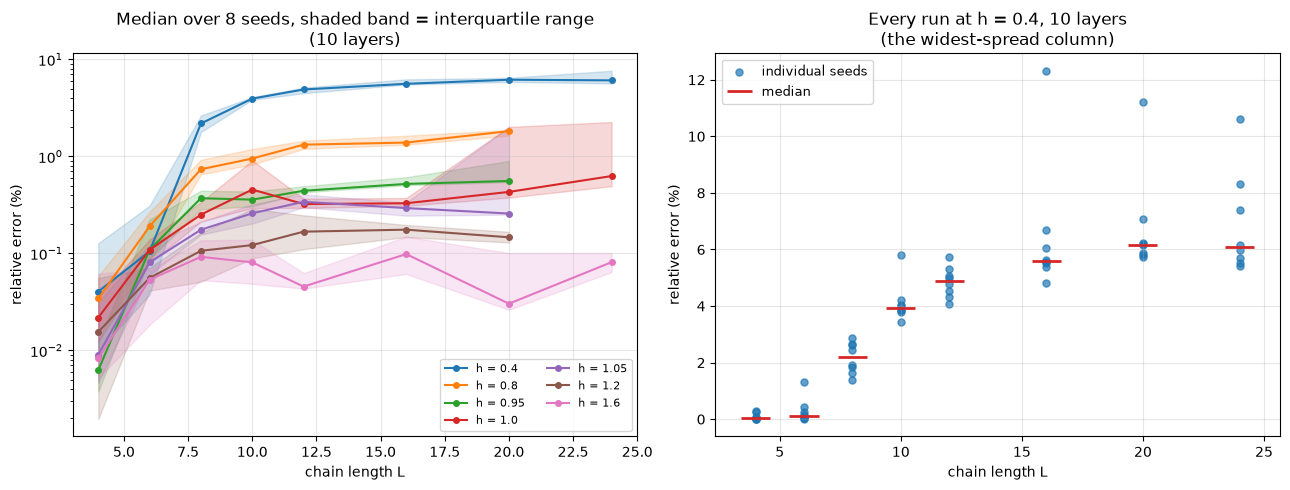

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for h in h_values:
    Ls = [L for L in L_values if (L, h, 10) in ens]
    if not Ls:
        continue
    med = np.array([ens[(L, h, 10)]["rel_error"]["median"] * 100 for L in Ls])
    q1 = np.array([ens[(L, h, 10)]["rel_error"]["q1"] * 100 for L in Ls])
    q3 = np.array([ens[(L, h, 10)]["rel_error"]["q3"] * 100 for L in Ls])
    line, = ax1.plot(Ls, med, "o-", label=f"h = {h}", markersize=4)
    ax1.fill_between(Ls, q1, q3, alpha=0.18, color=line.get_color())

ax1.set_yscale("log")
ax1.set_xlabel("chain length L")
ax1.set_ylabel("relative error (%)")
ax1.set_title("Median over 8 seeds, shaded band = interquartile range\n(10 layers)")
ax1.legend(fontsize=8, ncol=2)
ax1.grid(alpha=0.3)

Ls04 = [L for L in L_values if (L, 0.4, 10) in ens]
for L in Ls04:
    vals = np.array(ens[(L, 0.4, 10)]["rel_error"]["values"]) * 100
    ax2.scatter([L] * len(vals), vals, s=26, alpha=0.7, color="tab:blue",
                label="individual seeds" if L == Ls04[0] else None)
    ax2.hlines(ens[(L, 0.4, 10)]["rel_error"]["median"] * 100, L - 0.6, L + 0.6,
               color="tab:red", lw=2,
               label="median" if L == Ls04[0] else None)

ax2.set_xlabel("chain length L")
ax2.set_ylabel("relative error (%)")
ax2.set_title("Every run at h = 0.4, 10 layers\n(the widest-spread column)")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(REPO_ROOT / "figures" / "vqe_seed_spread.png", dpi=150, bbox_inches="tight")
plt.show()

## Is the optimizer rewrite responsible for any of this?

`results/vqe_sim/` was produced by the older autograd optimizer; everything here uses
the JAX/optax path. If that change introduced a systematic bias, comparing old numbers
to new ones would be meaningless.

It did not. Holding the seed fixed at 0 and running the same configuration on both
code paths, the shift is unbiased and its scatter is the same size as the
seed-to-seed scatter — so switching optimizer is statistically indistinguishable from
switching seed. The old values are not wrong; they are simply another single draw,
and this ensemble supersedes them without contradicting them.

In [11]:
old_dir = REPO_ROOT / "results" / "vqe_sim"
shifts = []
for L_dir in sorted(old_dir.glob("*"), key=lambda p: int(p.name)):
    for f in sorted(L_dir.glob("*.json")):
        old = json.loads(f.read_text())
        if old.get("n_layers") != 10 or old.get("seed") != 0:
            continue
        new_f = (REPO_ROOT / "results" / "vqe_seeds" / str(old["L"]) /
                 f"{old['h']:.3f}_layers10_seed0.json")
        if not new_f.exists():
            continue
        new = json.loads(new_f.read_text())
        shifts.append((new["rel_error"] - old["rel_error"]) * 100)

shifts = np.array(shifts)
seed_stds = np.array([e["rel_error"]["std"] * 100 for e in ens.values()])
print(f"same seed, both code paths: n = {len(shifts)} configurations")
print(f"  mean shift      {shifts.mean():+.3f} pp   (a bias would show up here)")
print(f"  std of shift     {shifts.std(ddof=1):.3f} pp")
print(f"  largest |shift|  {np.abs(shifts).max():.3f} pp")
print(f"\nfor comparison, median seed-to-seed std across configurations: "
      f"{np.median(seed_stds):.3f} pp")

same seed, both code paths: n = 49 configurations
  mean shift      +0.002 pp   (a bias would show up here)
  std of shift     0.109 pp
  largest |shift|  0.346 pp

for comparison, median seed-to-seed std across configurations: 0.199 pp


## What this means for the write-up

- **Report medians and interquartile ranges, not `mean ± std`.** The distributions are
  right-skewed and a single bad run moves the mean noticeably.
- **The near-critical problem at `L=20` is a reliability problem, not an accuracy
  one.** Runs that converge are about as good as at `L=16`; what grows with system
  size is how often the optimizer fails. Describe it as a failure rate, with the count
  of failed seeds, rather than as an error that increases.
- **Depth does not repair it.** Converged accuracy at `L=20`, `h=1.0` is flat from 10
  to 24 layers. The apparent "6.4% to 0.6% repair" in the earlier write-up compares one
  failed 10-layer run against deeper runs that happened to converge.
- **16 versus 24 layers is not a result either**, so "plateaus at 24 layers" should not
  be claimed in any direction.
- **Do not draw a scaling law through the `L` dependence.** The non-monotonicity that
  motivated one is optimizer scatter and vanishes on averaging.
- **Two of the published single-run numbers are tail draws** rather than typical runs,
  which is a concrete reason to quote the ensemble instead of the single values.

## One more reason single-seed results mislead: the failures are correlated

The four near-critical values in the earlier write-up — at `h` = 0.95, 1.0, 1.05 and
1.2 — all sit around 6-7%, and their agreement with one another is what made the
"cliff" persuasive. Four separate values of `h` appearing to say the same thing looks
like strong evidence.

They are all the same seed. And that seed is the one initialization that fails across
the whole near-critical region, because the optimization landscape changes smoothly
with `h` and every run started from identical parameters. So the four numbers are not
four independent measurements agreeing; they are one failure counted four times.

The cell below shows which seeds exceed 1% at each `h`.

In [12]:
print(f"{'h':<7}{'failed':>8}{'failing seeds':>22}{'converged range':>22}")
for h in h_values:
    e = ens.get((20, h, 10))
    if e is None:
        continue
    pairs = sorted(zip(e["seeds"], e["rel_error"]["values"]))
    bad = [s for s, v in pairs if v > 0.01]
    good = [v for _, v in pairs if v <= 0.01]
    n = len(pairs)
    seeds = ",".join(str(s) for s in bad) if bad else "-"
    rng = f"{min(good)*100:.2f}-{max(good)*100:.2f}%" if good else "none converged"
    print(f"{h:<7}{f'{len(bad)}/{n}':>8}{seeds:>22}{rng:>22}")

h        failed         failing seeds       converged range
0.4         8/8       0,1,2,3,4,5,6,7        none converged
0.8         8/8       0,1,2,3,4,5,6,7        none converged
0.95        1/8                     0            0.45-0.92%
1.0         2/8                   0,4            0.36-0.55%
1.05        2/8                   0,4            0.22-0.35%
1.2         1/8                     0            0.09-0.17%
1.6         0/8                     -            0.02-0.30%
